In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from IPython.display import display

!pip install seaborn
!pip install geopandas

import geopandas as gpd


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Loading larger dataset
all_tracts = pd.read_csv('NRI_Table_CensusTracts.csv')

In [3]:
## Read the Census Tracts data
tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')

##Verifications for Shape files
tracts.head()

###This checks for Coordinate Reference System (CRS)
tracts.crs

###Checks the geometries in the data
tracts.geometry.head()
#cleaning file
tracts_clean = tracts.set_crs(epsg=4326, inplace = True, allow_override=True)

# transform to a new CRS (e.g., Pseudo-Mercator)
tracts_clean = tracts_clean.to_crs(epsg=4326)

# Replace -9999 nulls with NaN
tracts_clean = tracts_clean.replace(-9999, np.nan)

# 1. Tell GeoPandas the data is actually Web Mercator (meters)
tracts_clean.crs = "EPSG:3857"
# 2. Now properly convert it to degrees to match your xlim/ylim
tracts_clean = tracts_clean.to_crs(epsg=4326)

# Standard projection for US National maps
tracts_clean = tracts_clean.to_crs("ESRI:102003")

# List of states/territories to exclude - we will plot the lower 48
exclude = ['Alaska', 'Hawaii', 'Puerto Rico', 'American Samoa', 
           'Guam', 'Northern Mariana Islands', 'Virgin Islands']

# Filter if your column is named 'STATE'
tracts_lower48 = tracts_clean[~tracts_clean['STATE'].isin(exclude)]

## Vermont

In [4]:
#Filtering the Large dataset (NRI_Table_CenusTracts.csv) to only contain data for the state of Vermont.
vermont_tracts = all_tracts[all_tracts["STATE"] == "Vermont"]
#Converting the filtered data to a .csv file
vermont_tracts.to_csv('vermont_state_tracts.csv')

In [12]:
#loading datasets
vt_nri = pd.read_csv('vermont_state_tracts.csv')
vt_svi= pd.read_csv("Vermont.csv")

In [13]:
# merging data sets and removing duplicates
vt_nri['STCNTY'] = vt_nri['STCOFIPS']
vermont_complete_data = pd.merge(vt_nri, vt_svi, on = 'STCNTY', suffixes=('', '_right'))

In [14]:
#Columns are missing, so it is best to remove columns of missing data. 
vt_clean = vt_nri.dropna(axis = 1).copy()

In [36]:
#We are combinging frequecny and exposure for each disaster, then divide it by the community resilience
#As an example, we chose to calculate the risk for winter weather.

vt_clean.loc[:, 'vt_wntw_risk'] = (
    vt_clean['WNTW_EXPT']*vt_clean['WNTW_AFREQ']/vt_clean['RESL_VALUE']
)
#combining for the tracts_clean to create map
tracts_clean.loc[:, 'vt_wntw_risk'] = (
    tracts_clean['WNTW_EXPT']*tracts_clean['WNTW_AFREQ']/tracts_clean['RESL_VALUE']
)

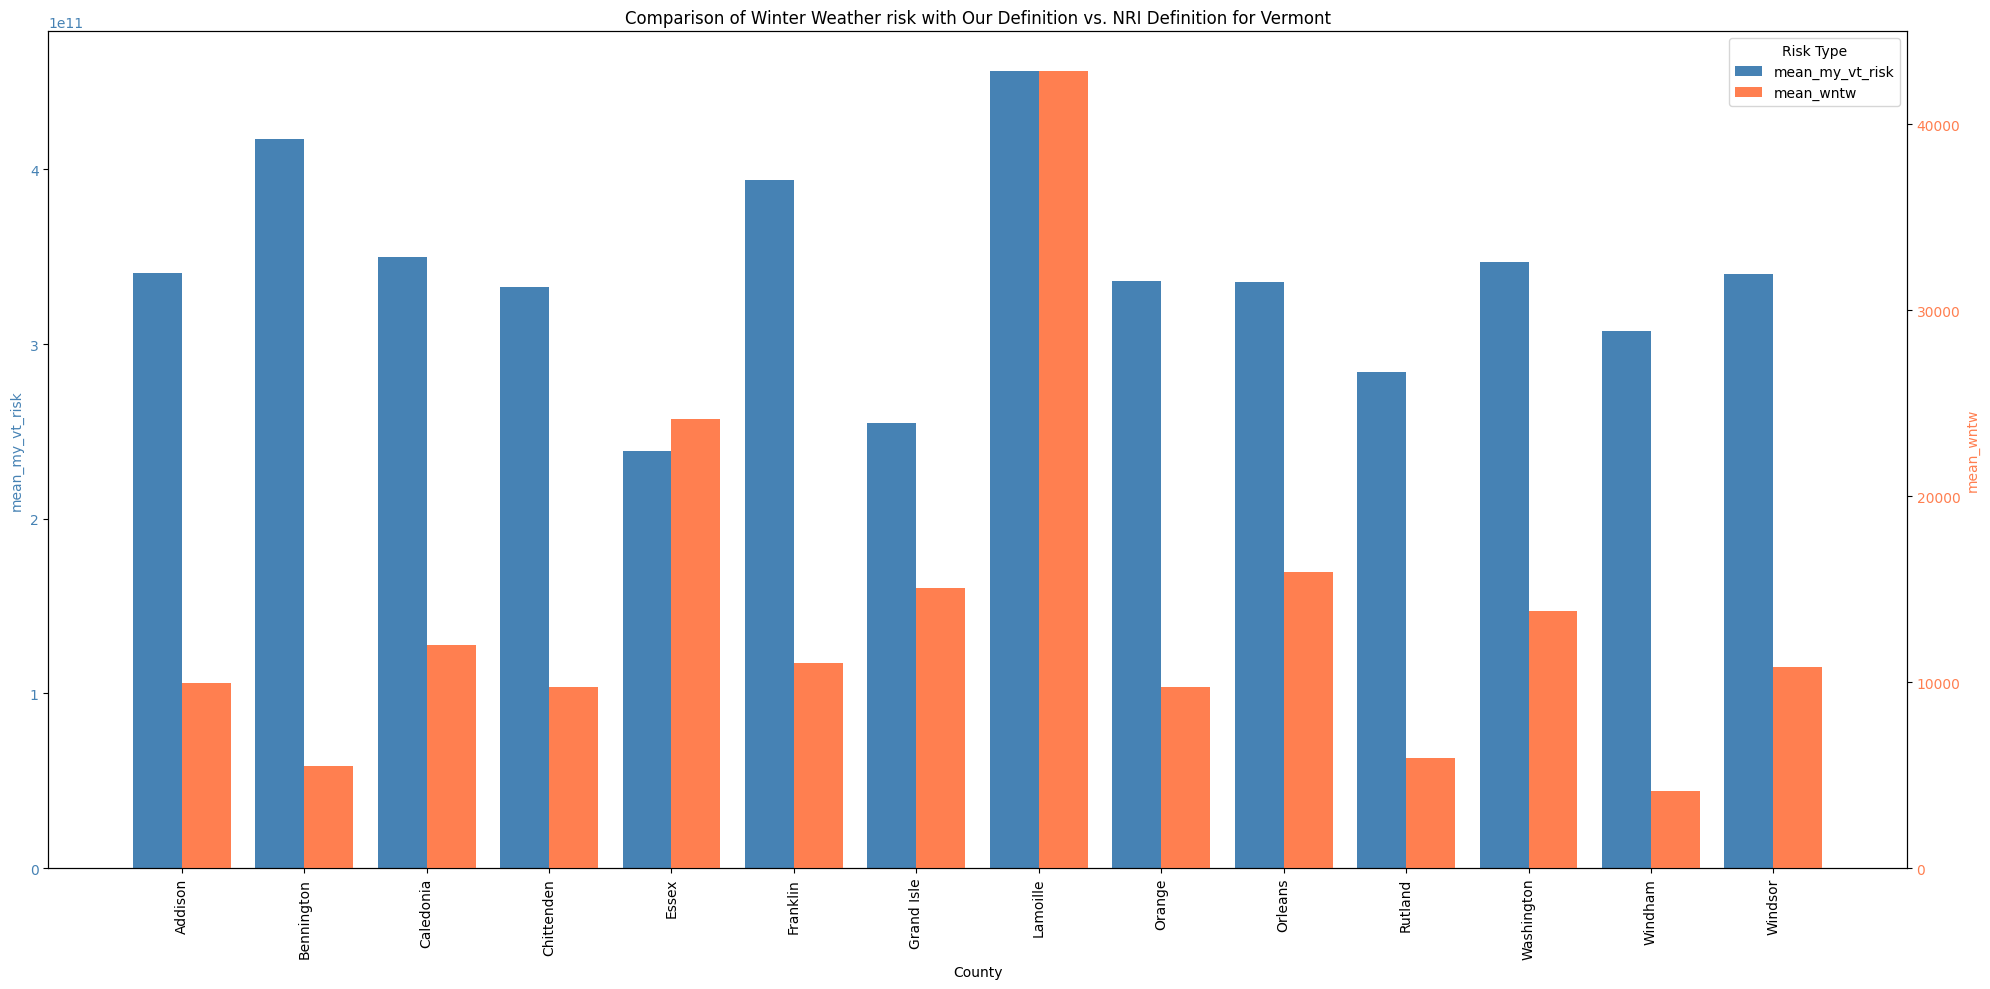

In [37]:
#Grouping Our risk values and the NRI risk value for Winter Weather
grouped_vtdata = vt_clean.groupby('COUNTY',as_index=False)
grouped_vtdata = vt_clean.groupby('COUNTY').agg(mean_my_vt_risk=('vt_wntw_risk', 'mean'), 
                                                   mean_wntw=('WNTW_RISKV', 'mean'))
fig, ax1= plt.subplots(figsize=(20,10))
x = range(len(grouped_vtdata))
width = 0.4
ax1.bar([i-width/2 for i in x], grouped_vtdata.iloc[:, 0], width=width, color='steelblue', label=grouped_vtdata.columns[0])
ax1.set_ylabel(grouped_vtdata.columns[0], color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2= ax1.twinx()
ax2.bar([i+width/2 for i in x], grouped_vtdata.iloc[:, 1], width=width, color='coral', label=grouped_vtdata.columns[1])
ax2.set_ylabel(grouped_vtdata.columns[1], color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

ax1.set_xticks(x)
ax1.set_xticklabels(grouped_vtdata.index, rotation=90)
ax1.set_xlabel('County')

plt.title('Comparison of Winter Weather risk with Our Definition vs. NRI Definition for Vermont')

lines1, labels1=ax1.get_legend_handles_labels()
lines2, labels2=ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, title="Risk Type")
plt.tight_layout()
plt.show()

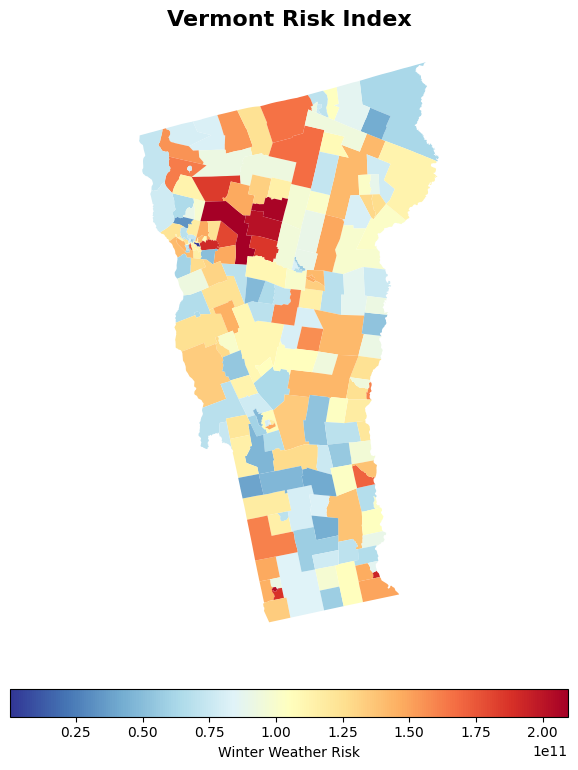

In [48]:
# Map of Vermont illustarting the risk
state_name = "Vermont"
state_map = tracts_clean[tracts_clean["STATE"] == state_name]
fig, ax = plt.subplots(1, 1, figsize=(12,10))

state_map.plot(
    column="vt_wntw_risk",
    cmap="RdYlBu_r",
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={"label": "Winter Weather Risk", "orientation":"horizontal", "shrink": 0.6, "pad":0.05},
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)

ax.set_title("Vermont Risk Index", fontsize=16, fontweight="bold")
ax.set_axis_off()

plt.show()

## Maine

In [39]:
#Filtering the Large dataset to only contain data for the state of Maine.
maine_tracts = all_tracts[all_tracts["STATE"] == "Maine"]
#Converting the filtered data to a .csv file
maine_tracts.to_csv('maine_state_tracts.csv')

In [40]:
#loading datasets
me_nri = pd.read_csv('maine_state_tracts.csv')
me_svi= pd.read_csv("Maine.csv")

In [41]:
# merging data sets and removing duplicates
me_nri['STCNTY'] = me_nri['STCOFIPS']
maine_complete_data = pd.merge(me_nri, me_svi, on = 'STCNTY', suffixes=('', '_right'))

In [42]:
#dropping columns with missing data
me_clean = me_nri.dropna(axis = 1).copy()

In [43]:
#We are combinging frequecny and exposure for each disaster, then divide it by the community resilience
#As an example, we chose to calculate the risk for winter weather.
me_clean.loc[:, 'me_wntw_risk'] = (
    me_clean['WNTW_EXPT']*me_clean['WNTW_AFREQ']/me_clean['RESL_VALUE']
)
#creating column for tracts_clean in order to create map
tracts_clean.loc[:, 'me_wntw_risk'] = (
    tracts_clean['WNTW_EXPT']*tracts_clean['WNTW_AFREQ']/tracts_clean['RESL_VALUE']
)

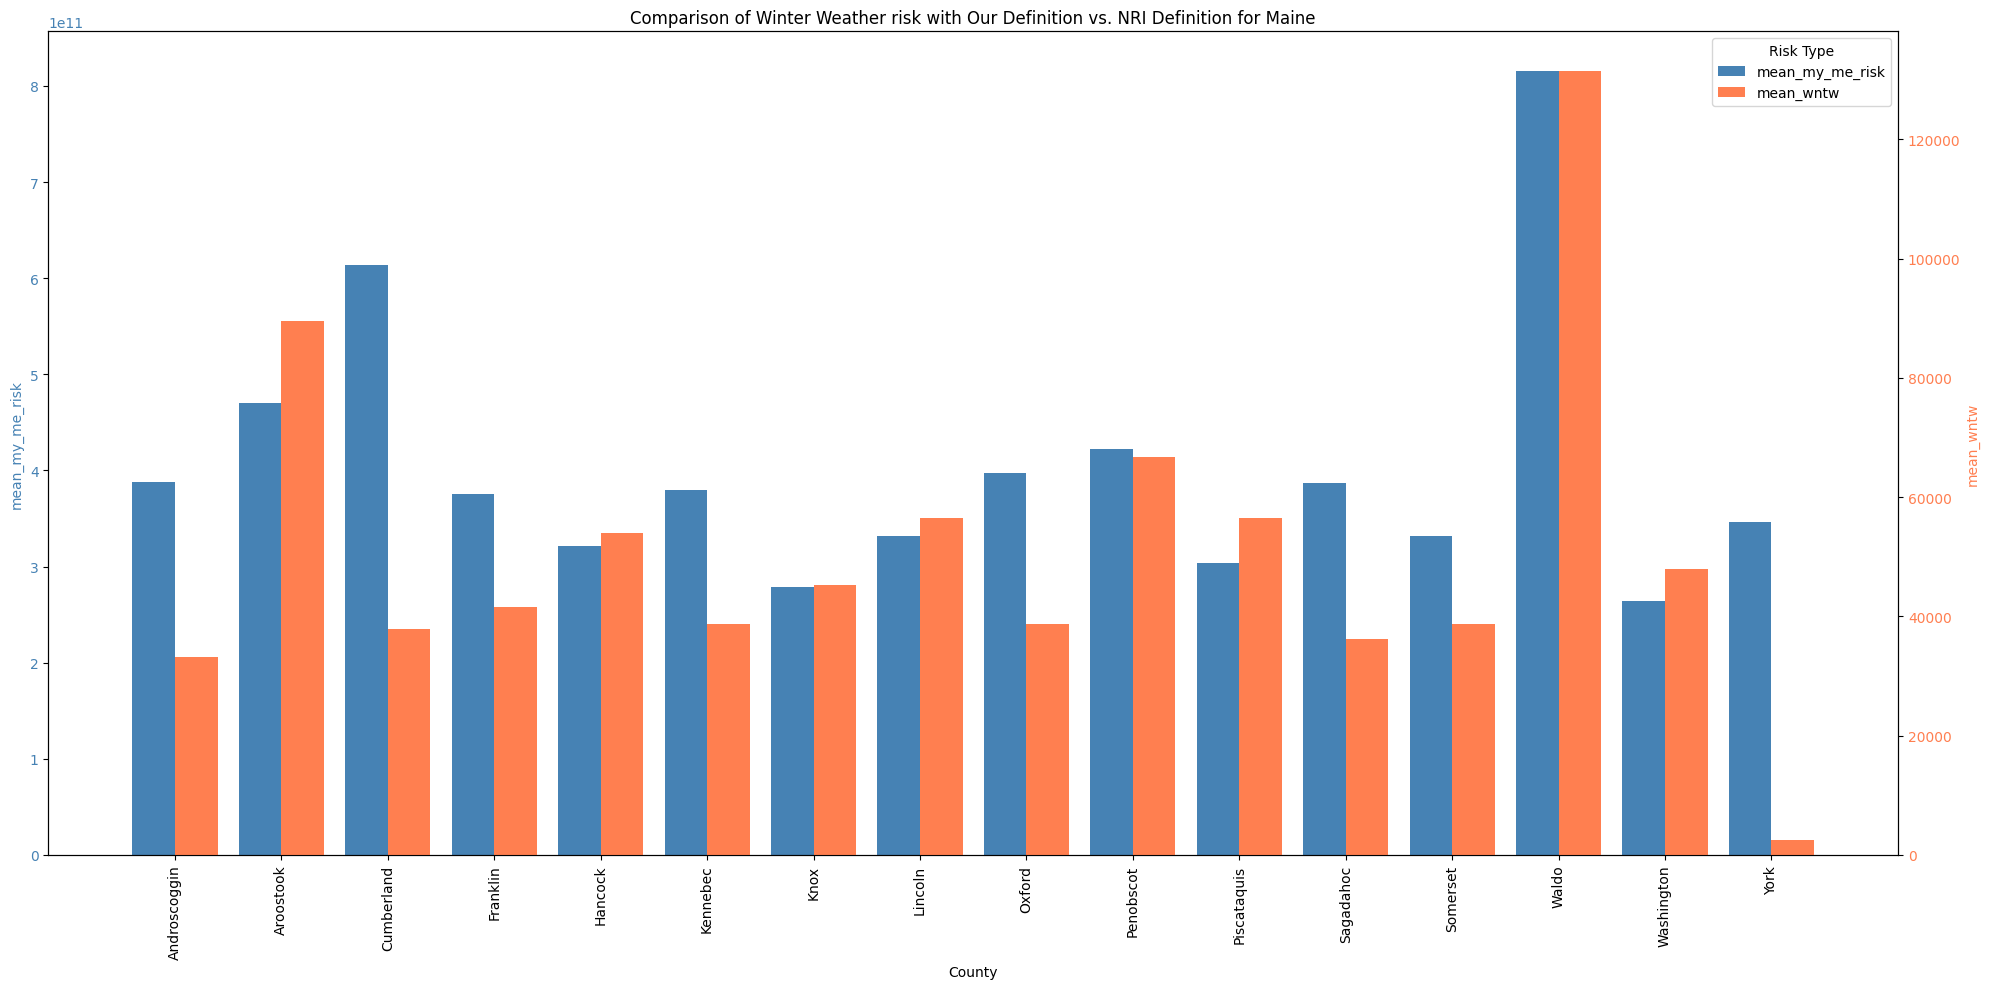

In [44]:
#Grouping Our risk values and the NRI risk value for Winter Weather
grouped_medata = me_clean.groupby('COUNTY',as_index=False)
grouped_medata = me_clean.groupby('COUNTY').agg(mean_my_me_risk=('me_wntw_risk', 'mean'), 
                                                   mean_wntw=('WNTW_RISKV', 'mean'))
fig, ax1= plt.subplots(figsize=(20,10))
x = range(len(grouped_medata))
width = 0.4
ax1.bar([i-width/2 for i in x], grouped_medata.iloc[:, 0], width=width, color='steelblue', label=grouped_medata.columns[0])
ax1.set_ylabel(grouped_medata.columns[0], color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2= ax1.twinx()
ax2.bar([i+width/2 for i in x], grouped_medata.iloc[:, 1], width=width, color='coral', label=grouped_medata.columns[1])
ax2.set_ylabel(grouped_medata.columns[1], color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

ax1.set_xticks(x)
ax1.set_xticklabels(grouped_medata.index, rotation=90)
ax1.set_xlabel('County')

plt.title('Comparison of Winter Weather risk with Our Definition vs. NRI Definition for Maine')

lines1, labels1=ax1.get_legend_handles_labels()
lines2, labels2=ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, title="Risk Type")
plt.tight_layout()
plt.show()

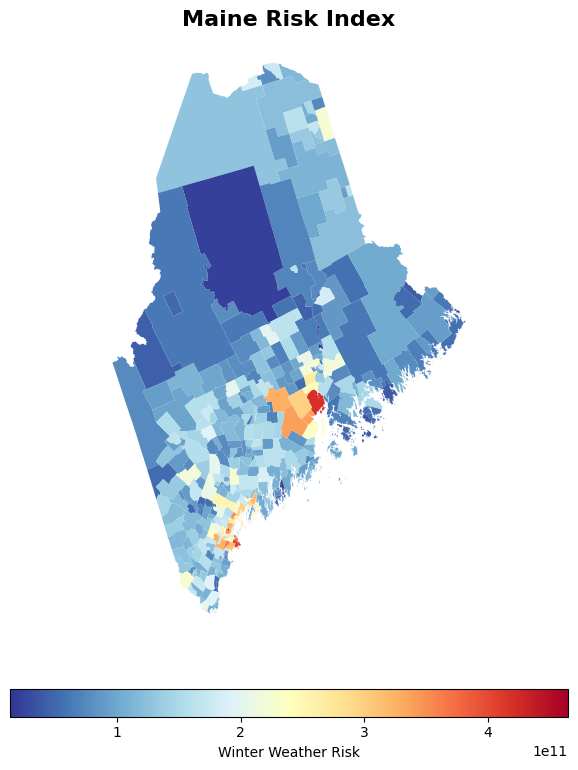

In [47]:
state_name = "Maine"
state_map = tracts_clean[tracts_clean["STATE"] == state_name]
fig, ax = plt.subplots(1, 1, figsize=(12,10))

state_map.plot(
    column="me_wntw_risk",
    cmap="RdYlBu_r",
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={"label": "Winter Weather Risk", "orientation":"horizontal", "shrink": 0.6, "pad":0.05},
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)

ax.set_title("Maine Risk Index", fontsize=16, fontweight="bold")
ax.set_axis_off()

plt.show()